# Семинар 1
# Основы PyTorch с примерами
Этот ноутбук объединяет базовые элементы PyTorch и пример обучения нейросети в единую последовательную траекторию от простых операций к обучаемой модели.

---

## 1. Знакомство с PyTorch и тензорами
В этом разделе рассматриваются базовые сущности PyTorch — тензоры. Тензор является обобщением скаляров, векторов и матриц и служит основной структурой данных для всех вычислений в PyTorch.

Мы разберём создание тензоров, их формы, типы и базовые операции.

<h3 style="text-align: center;"><b>Введение</b></h3>

На текущее время было реализовано несколько различных фреймворков глубокого обучения. Разница между ними заключается во внутренних принципах вычислений. Например, в **[Caffe](http://caffe.berkeleyvision.org/)** и **[Caffe2](https://caffe2.ai/)** вы пишете код, используя некоторые «готовые блоки» (как и LEGO). На данный момент это уже история, сейчас **Caffe** стал частью **PyTorch**.
В **[TensorFlow](https://www.tensorflow.org/)** вы сначала объявляете граф вычислений, затем компилируйте его и используйте для вывода / обучения (`tf.session ()`). Кстати, теперь в TensorFlow (начиная с версии 1.10) есть функция [Eager Execution](https://www.tensorflow.org/guide/eager), которая может быть полезна для быстрого прототипирования и отладки. **[Keras](https://keras.io/)** - очень популярный и полезный фреймворк DL, который позволяет быстро реализовывать нейронный сети и имеет множество полезных функций.


Мы будем использовать **PyTorch**, поскольку он активно развивается и поддерживается AI-сообществом

<h3 style="text-align: center;"><b>Установка</b></h3>

Подробную инструкцию по установке PyTorch вы можете найти на [официальном сайте PyTorch](https://pytorch.org/).

In [105]:
! pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cu126

Looking in indexes: https://download.pytorch.org/whl/cu126


## Синтаксис Фреймворка

In [106]:
import torch

## 2. Автоматическое дифференцирование (autograd)
Ключевой особенностью PyTorch является автоматическое дифференцирование. Каждая операция над тензорами может быть включена в вычислительный граф, по которому затем автоматически вычисляются градиенты.

Этот механизм лежит в основе алгоритма обратного распространения ошибки.

Несколько фактов о PyTorch:
- динамический граф вычислений
- удобные модули `torch.nn` и `torchvision` для быстрого прототипирования нейронных сетей
- даже быстрее, чем TensorFlow на некоторых задачах
- позволяет легко использовать **GPU**

По своей сути PyTorch предоставляет две основные функции:

- n-мерный тензор, похожий на **numpy**, но может работать на графических процессорах
- Автоматическая дифференциация для построения и обучения нейронных сетей

Если бы PyTorch был формулой, она была бы такой:

$$PyTorch = NumPy + CUDA + Autograd$$

(CUDA - [wiki](https://en.wikipedia.org/wiki/CUDA))

Давайте посмотрим, как мы можем использовать PyTorch для работы с векторами и тензорами.

Напомним, что **тензор** - это многомерный вектор, например :

`x = np.array ([1,2,3])` - вектор = тензор с 1 размерностью (точнее: `(3,)`)

`y = np.array ([[1, 2, 3], [4, 5, 6]])` - матрица = тензор с двумя измерениями (`(2, 3)` в данном случае)

`z = np.array ([[[1, 2, 3], [4, 5, 6], [7, 8, 9]]],
               [[1, 2, 3], [4, 5, 6], [7, 8, 9]],
               [[1, 2, 3], [4, 5, 6], [7, 8, 9]]]) `-" куб "(3, 3, 3) = тензор с тремя измерениями (` ( 3, 3, 3) `в этом случае)


Одним из реальных примеров трехмерного тензора является **изображение**, оно имеет 3 измерения: `высота`, `ширина` и `глубина канала` (глубина канала = 3 для цветных изображений, 1 для оттенков серого). Вы можете думать об этом как о параллелепипеде, состоящем из действительных чисел.


### Типы Тензоров

В PyTorch мы будем использовать `torch.Tensor` (`FloatTensor`, `IntTensor`, `ByteTensor`) для всех вычислений.

Все типы:

In [107]:
torch.HalfTensor      # 16 бит, floating point
torch.FloatTensor     # 32 бита, floating point
torch.DoubleTensor    # 64 бита, floating point

torch.ShortTensor     # 16 бит, integer, signed
torch.IntTensor       # 32 бита, integer, signed
torch.LongTensor      # 64 бита, integer, signed

torch.CharTensor      # 8 бит, integer, signed
torch.ByteTensor      # 8 бит, integer, unsigned

torch.ByteTensor

### Создание тензора

## 3. Нейрон как модуль PyTorch
В данном разделе вводится понятие модуля (`nn.Module`) — базового строительного блока нейросетей в PyTorch. Мы рассмотрим линейный слой, функции активации и понятие прямого прохода.

In [108]:
a = torch.FloatTensor([1, 2])
a

tensor([1., 2.])

In [109]:
a.shape

torch.Size([2])

In [110]:
b = torch.FloatTensor([[1,2,3], [4,5,6]])
b

tensor([[1., 2., 3.],
        [4., 5., 6.]])

In [111]:
b.shape

torch.Size([2, 3])

In [112]:
x = torch.FloatTensor(2,3,4)

In [113]:
x

tensor([[[ 1.7385e-24,  0.0000e+00, -3.4440e-25,  4.3237e-41],
         [ 8.9683e-44,  0.0000e+00,  1.1210e-43,  0.0000e+00],
         [ 1.7282e-24,  0.0000e+00,  7.4399e+28,  1.8063e+28]],

        [[ 1.5787e-19,  3.0262e+29,  1.5937e-10,  3.0880e+29],
         [ 4.5840e+30,  7.5431e+34,  2.1774e-10,  8.4833e+26],
         [ 1.8179e+31,  7.1776e+22,  1.8320e+25,  3.2957e+24]]])

In [114]:
x = torch.FloatTensor(100)
x

tensor([ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  9.1835e-41,  0.0000e+00,  1.4714e-43,  4.3164e-39,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         1.6483e-24,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  1.1020e-38,  8.9081e-39,  9.4592e-39,
         1.0469e-38,  1.0653e-38,  1.0010e-38,  4.2246e-39,  9.6429e-39,
         8.9082e-39,  1.0653e-38,  1.0653e-38,  4.2246e-39,  8.9082e-39,
         1.0469e-38,  1.1020e-38,  8.9999e-39,  8.9080e-39,  0.0000e+00,
         4.7084e-43,  0.0000e+00,  2.6905e-43,  0.0000e+00, -1.8580e-36,
         4.3237e-41,  0.0000e+00,  0.0000e+00,  1.6

In [115]:
x = torch.IntTensor(45, 57, 14, 2)
x.shape

torch.Size([45, 57, 14, 2])

**Примечание:** если вы создаете `torch.Tensor` с помощью следующего конструктора, он будет заполнен "мусором" из случайных чисел:

In [116]:
x = torch.IntTensor(3, 2, 4)
x

tensor([[[-1764414016,       30855,   402780144,           0],
         [   16842753,           0,           0,       65536]],

        [[          0,           0,    16842752,    16843009],
         [   16843009,    16843009,       65793,       65537]],

        [[        257,       65537,       65536,           0],
         [          0,           0,           0,           1]]],
       dtype=torch.int32)

### Инициализации тензоров

In [117]:
x1 = torch.FloatTensor(3, 2, 4)
x1.zero_()
x2 = torch.zeros(3, 2, 4)
x3 = torch.zeros_like(x1)

assert torch.allclose(x1, x2) and torch.allclose(x1, x3)

Инициализация случайного распределения

In [118]:
x = torch.randn((2,3))                # Normal(0, 1) с размером (2, 3)
x

tensor([[ 0.0783,  1.7700,  1.4350],
        [ 0.1637, -1.0562, -0.3650]])

In [119]:
print(x.random_(0, 10))                      # Дискретное равномерно U[0, 10]
print(x.uniform_(0, 1))                      # Равномерно U[0, 1]
print(x.normal_(mean=0, std=1))              # Нормальное со средним 0 и дисперсией 1
print(x.bernoulli_(p=0.5))                   # bernoulli with parameter p

tensor([[3., 1., 9.],
        [6., 5., 3.]])
tensor([[0.9580, 0.2009, 0.2509],
        [0.0256, 0.7359, 0.1004]])
tensor([[-0.1377, -0.7095, -0.1746],
        [ 0.1424, -2.5134,  0.2570]])
tensor([[0., 0., 1.],
        [1., 0., 1.]])


## Функции в Torch

У всех функций Numpy есть своя пара в Torch.

https://github.com/torch/torch7/wiki/Torch-for-Numpy-users

### Изменение формы
`np.reshape()` == `torch.view()`:

In [120]:
b

tensor([[1., 2., 3.],
        [4., 5., 6.]])

In [121]:
b.view(3, 2).shape

torch.Size([3, 2])

**Примечание:** `torch.view ()` создает новый тензор, но старый остается неизменным

In [122]:
b.view(-1, 2)

tensor([[1., 2.],
        [3., 4.],
        [5., 6.]])

In [123]:
b

tensor([[1., 2., 3.],
        [4., 5., 6.]])

### Изменение типа тензора

In [124]:
a = torch.FloatTensor([1.5, 3.2, -7])

In [125]:
a.type_as(torch.IntTensor())

tensor([ 1,  3, -7], dtype=torch.int32)

In [126]:
a.to(torch.int32)

tensor([ 1,  3, -7], dtype=torch.int32)

In [127]:
a.type_as(torch.ByteTensor())

tensor([  1,   3, 249], dtype=torch.uint8)

In [128]:
a.to(torch.uint8)

tensor([  1,   3, 249], dtype=torch.uint8)

In [129]:
a

tensor([ 1.5000,  3.2000, -7.0000])

* Indexing is just like in `NumPy`:

In [130]:
a = torch.FloatTensor([[100, 20, 35], [15, 163, 534], [52, 90, 66]])
a

tensor([[100.,  20.,  35.],
        [ 15., 163., 534.],
        [ 52.,  90.,  66.]])

In [131]:
a[0, 0]

tensor(100.)

In [132]:
a[0:2, 1]

tensor([ 20., 163.])

### Арифметические операции

| операция | аналоги |
|:-:|:-:|
|`+`| `torch.add()` |
|`-`| `torch.sub()` |
|`*`| `torch.mul()` |
|`/`| `torch.div()` |

#### Сложение

In [133]:
a = torch.FloatTensor([[1, 2, 3], [10, 20, 30], [100, 200, 300]])
b = torch.FloatTensor([[-1, -2, -3], [-10, -20, -30], [100, 200, 300]])

In [134]:
a + b

tensor([[  0.,   0.,   0.],
        [  0.,   0.,   0.],
        [200., 400., 600.]])

In [135]:
a.add(b)

tensor([[  0.,   0.,   0.],
        [  0.,   0.,   0.],
        [200., 400., 600.]])

In [136]:
b = -a
b

tensor([[  -1.,   -2.,   -3.],
        [ -10.,  -20.,  -30.],
        [-100., -200., -300.]])

In [137]:
a + b

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])

#### Вычитание

In [138]:
a - b

tensor([[  2.,   4.,   6.],
        [ 20.,  40.,  60.],
        [200., 400., 600.]])

In [139]:
a.sub(b) # copy

tensor([[  2.,   4.,   6.],
        [ 20.,  40.,  60.],
        [200., 400., 600.]])

In [140]:
a.sub_(b) # inplace

tensor([[  2.,   4.,   6.],
        [ 20.,  40.,  60.],
        [200., 400., 600.]])

#### Умножение (поэлементное)

In [141]:
a * b

tensor([[-2.0000e+00, -8.0000e+00, -1.8000e+01],
        [-2.0000e+02, -8.0000e+02, -1.8000e+03],
        [-2.0000e+04, -8.0000e+04, -1.8000e+05]])

In [142]:
a.mul(b)

tensor([[-2.0000e+00, -8.0000e+00, -1.8000e+01],
        [-2.0000e+02, -8.0000e+02, -1.8000e+03],
        [-2.0000e+04, -8.0000e+04, -1.8000e+05]])

#### Деление (поэлементное):

In [143]:
a = torch.FloatTensor([[1, 2, 3], [10, 20, 30], [100, 200, 300]])
b = torch.FloatTensor([[-1, -2, -3], [-10, -20, -30], [100, 200, 300]])

In [144]:
a / b

tensor([[-1., -1., -1.],
        [-1., -1., -1.],
        [ 1.,  1.,  1.]])

In [145]:
a.div(b)

tensor([[-1., -1., -1.],
        [-1., -1., -1.],
        [ 1.,  1.,  1.]])

**Примечание:** все эти операции создают новые тензоры, старые тензоры остаются неизменными.

In [146]:
a

tensor([[  1.,   2.,   3.],
        [ 10.,  20.,  30.],
        [100., 200., 300.]])

In [147]:
b

tensor([[ -1.,  -2.,  -3.],
        [-10., -20., -30.],
        [100., 200., 300.]])

### Операторы сравнения

In [148]:
a = torch.FloatTensor([[1, 2, 3], [10, 20, 30], [100, 200, 300]])
b = torch.FloatTensor([[-1, -2, -3], [-10, -20, -30], [100, 200, 300]])

In [149]:
a == b

tensor([[False, False, False],
        [False, False, False],
        [ True,  True,  True]])

In [150]:
a != b

tensor([[ True,  True,  True],
        [ True,  True,  True],
        [False, False, False]])

In [151]:
a < b

tensor([[False, False, False],
        [False, False, False],
        [False, False, False]])

In [152]:
a > b

tensor([[ True,  True,  True],
        [ True,  True,  True],
        [False, False, False]])

### Использование индексации по логической маске

In [153]:
a[a > b]

tensor([ 1.,  2.,  3., 10., 20., 30.])

In [154]:
b[a == b]

tensor([100., 200., 300.])

### Поэлементное применение **универсальных функций**

In [155]:
a = torch.FloatTensor([[1, 2, 3], [10, 20, 30], [100, 200, 300]])

In [156]:
a.sin()

tensor([[ 0.8415,  0.9093,  0.1411],
        [-0.5440,  0.9129, -0.9880],
        [-0.5064, -0.8733, -0.9998]])

In [157]:
torch.sin(a)

tensor([[ 0.8415,  0.9093,  0.1411],
        [-0.5440,  0.9129, -0.9880],
        [-0.5064, -0.8733, -0.9998]])

In [158]:
a.tan()

tensor([[ 1.5574, -2.1850, -0.1425],
        [ 0.6484,  2.2372, -6.4053],
        [-0.5872, -1.7925, 45.2447]])

In [159]:
a.exp()

tensor([[2.7183e+00, 7.3891e+00, 2.0086e+01],
        [2.2026e+04, 4.8517e+08, 1.0686e+13],
        [       inf,        inf,        inf]])

In [160]:
a.log()

tensor([[0.0000, 0.6931, 1.0986],
        [2.3026, 2.9957, 3.4012],
        [4.6052, 5.2983, 5.7038]])

In [161]:
b = -a
b

tensor([[  -1.,   -2.,   -3.],
        [ -10.,  -20.,  -30.],
        [-100., -200., -300.]])

In [162]:
b.abs()

tensor([[  1.,   2.,   3.],
        [ 10.,  20.,  30.],
        [100., 200., 300.]])

## Матричные операции

#### Транспонирование тензора

In [163]:
a = torch.FloatTensor([[1, 2, 3], [10, 20, 30], [100, 200, 300]])
a

tensor([[  1.,   2.,   3.],
        [ 10.,  20.,  30.],
        [100., 200., 300.]])

In [164]:
a.t()

tensor([[  1.,  10., 100.],
        [  2.,  20., 200.],
        [  3.,  30., 300.]])

Это тоже не inplace-операция:

In [165]:
a

tensor([[  1.,   2.,   3.],
        [ 10.,  20.,  30.],
        [100., 200., 300.]])

#### Скалярное произведение векторов

In [166]:
a = torch.FloatTensor([1, 2, 3, 4, 5, 6])
b = torch.FloatTensor([-1, -2, -4, -6, -8, -10])

In [167]:
a.dot(b)

tensor(-141.)

In [168]:
a.shape, b.shape

(torch.Size([6]), torch.Size([6]))

In [169]:
a @ b

tensor(-141.)

In [170]:
type(a)

torch.Tensor

In [171]:
type(b)

torch.Tensor

In [172]:
type(a @ b)

torch.Tensor

#### Матричное произведение

In [173]:
a = torch.FloatTensor([[1, 2, 3], [10, 20, 30], [100, 200, 300]])
b = torch.FloatTensor([[-1, -2, -3], [-10, -20, -30], [100, 200, 300]])

In [174]:
a.mm(b)

tensor([[  279.,   558.,   837.],
        [ 2790.,  5580.,  8370.],
        [27900., 55800., 83700.]])

In [175]:
a @ b

tensor([[  279.,   558.,   837.],
        [ 2790.,  5580.,  8370.],
        [27900., 55800., 83700.]])

In [176]:
a = torch.FloatTensor([[1, 2, 3], [10, 20, 30], [100, 200, 300]])
b = torch.FloatTensor([[-1], [-10], [100]])

In [177]:
print(a.shape, b.shape)

torch.Size([3, 3]) torch.Size([3, 1])


In [178]:
a @ b

tensor([[  279.],
        [ 2790.],
        [27900.]])

Тензор `b` можно развернуть в одномерный массив с помощью функции `torch.view(-1)`, чтобы результат был вектором

In [179]:
b

tensor([[ -1.],
        [-10.],
        [100.]])

In [180]:
b.view(-1)

tensor([ -1., -10., 100.])

In [181]:
a @ b.view(-1)

tensor([  279.,  2790., 27900.])

In [182]:
a.mv(b.view(-1))

tensor([  279.,  2790., 27900.])

In [183]:
y = torch.Tensor(2, 3, 4, 5)
z = torch.Tensor(2, 3, 5, 6)
(y @ z).shape

torch.Size([2, 3, 4, 6])

## Конвертация
#### Конвертация из Numpy в Pytorch:

In [184]:
import numpy as np

a = np.random.rand(3, 3)
a

array([[0.30427857, 0.07902263, 0.20896616],
       [0.34888517, 0.2012197 , 0.38724362],
       [0.22406403, 0.13434049, 0.90597053]])

In [185]:
b = torch.from_numpy(a)
b

tensor([[0.3043, 0.0790, 0.2090],
        [0.3489, 0.2012, 0.3872],
        [0.2241, 0.1343, 0.9060]], dtype=torch.float64)

**Внимание!** `a` и `b` хранятся в одной и той же ячейке данных. Если именить один тензор, то изменится и другой.

In [186]:
b -= b
b

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]], dtype=torch.float64)

In [187]:
a

array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]])

#### Конвертация из Torch в Numpy

In [188]:
a = torch.FloatTensor(2, 3, 4)
a

tensor([[[2.6312e+20, 2.5811e-09, 3.2480e-09, 2.4828e-18],
         [3.1360e+27, 7.0800e+31, 3.1095e-18, 4.7851e+22],
         [2.8826e+32, 4.4248e+30, 7.6729e+34, 2.1707e-18]],

        [[4.5447e+30, 7.0062e+22, 2.1715e-18, 4.5447e+30],
         [7.0062e+22, 2.1707e-18, 1.9284e+31, 3.2314e-18],
         [9.4370e-09, 5.2299e+22, 1.0368e-11, 6.7020e-10]]])

In [189]:
type(a)

torch.Tensor

In [190]:
x = a.numpy()
x

array([[[2.63123705e+20, 2.58110178e-09, 3.24798721e-09, 2.48277020e-18],
        [3.13596656e+27, 7.07995849e+31, 3.10948297e-18, 4.78511153e+22],
        [2.88259135e+32, 4.42481962e+30, 7.67288557e+34, 2.17074072e-18]],

       [[4.54474536e+30, 7.00623823e+22, 2.17148187e-18, 4.54474536e+30],
        [7.00623823e+22, 2.17074072e-18, 1.92838405e+31, 3.23139947e-18],
        [9.43696854e-09, 5.22990685e+22, 1.03677926e-11, 6.70203615e-10]]],
      dtype=float32)

In [191]:
x.shape

(2, 3, 4)

In [192]:
type(x)

numpy.ndarray

### Практика

1) Создайте случайный тензор A (из нормального распределения) размером (12,).

2) Измените форму тензора A так, чтобы получилась матрица 3x4.

3) Создайте второй тензор B размером (4x2), заполненный единицами.

4) Выполните матричное умножение тензоров A и B.

5) Примените к результату поэлементно любую математическую функцию (например, модуль или экспоненту).

## <h1 style="text-align: center;"><a href="https://ru.wikipedia.org/wiki/CUDA">CUDA</a></h3>

CUDA --- это программно-аппаратная архитектура параллельных вычислений, которая позволяет существенно увеличить вычислительную производительность благодаря использованию графических процессоров фирмы Nvidia. Для нас CUDA --- это драйвер, который позволяет нам проводить вычисления на GPU.

[CUDA documentation](https://docs.nvidia.com/cuda/)

Для вычислений на Pytorch мы можем использовать как CPU (Central Processing Unit), так и GPU (Graphical Processing Unit). Между ними можно легко переключаться, и это очень важно!

In [193]:
x = torch.FloatTensor(1024, 10024).uniform_()
x

tensor([[0.3009, 0.7425, 0.9542,  ..., 0.5744, 0.4372, 0.6639],
        [0.5032, 0.5590, 0.8022,  ..., 0.6221, 0.6435, 0.7753],
        [0.8313, 0.1357, 0.1168,  ..., 0.7944, 0.1194, 0.6965],
        ...,
        [0.9615, 0.1055, 0.2555,  ..., 0.0644, 0.7292, 0.3863],
        [0.3221, 0.5344, 0.1811,  ..., 0.4733, 0.9925, 0.8103],
        [0.6449, 0.7646, 0.9134,  ..., 0.0935, 0.3654, 0.9119]])

In [194]:
x.is_cuda

False

#### Кладём тензор на GPU

In [195]:
!nvidia-smi

Mon Mar  2 20:17:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   72C    P0             33W /   70W |    1349MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [196]:
x = x.cuda()

In [197]:
!nvidia-smi

Mon Mar  2 20:17:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   72C    P0             33W /   70W |    1349MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [198]:
x

tensor([[0.3009, 0.7425, 0.9542,  ..., 0.5744, 0.4372, 0.6639],
        [0.5032, 0.5590, 0.8022,  ..., 0.6221, 0.6435, 0.7753],
        [0.8313, 0.1357, 0.1168,  ..., 0.7944, 0.1194, 0.6965],
        ...,
        [0.9615, 0.1055, 0.2555,  ..., 0.0644, 0.7292, 0.3863],
        [0.3221, 0.5344, 0.1811,  ..., 0.4733, 0.9925, 0.8103],
        [0.6449, 0.7646, 0.9134,  ..., 0.0935, 0.3654, 0.9119]],
       device='cuda:0')

In [199]:
x = x.cpu()
!nvidia-smi

torch.cuda.empty_cache()
!nvidia-smi

Mon Mar  2 20:17:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   72C    P0             33W /   70W |    1349MiB /  15360MiB |      2%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [200]:
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")

x = x.to(device)
x

tensor([[0.3009, 0.7425, 0.9542,  ..., 0.5744, 0.4372, 0.6639],
        [0.5032, 0.5590, 0.8022,  ..., 0.6221, 0.6435, 0.7753],
        [0.8313, 0.1357, 0.1168,  ..., 0.7944, 0.1194, 0.6965],
        ...,
        [0.9615, 0.1055, 0.2555,  ..., 0.0644, 0.7292, 0.3863],
        [0.3221, 0.5344, 0.1811,  ..., 0.4733, 0.9925, 0.8103],
        [0.6449, 0.7646, 0.9134,  ..., 0.0935, 0.3654, 0.9119]],
       device='cuda:0')

Умножим два тензора в GPU и вернём результат обратно на CPU:

In [201]:
a = torch.FloatTensor(10000, 10000).uniform_()
b = torch.FloatTensor(10000, 10000).uniform_()
c = a.cuda().mul(b.cuda()).cpu()

In [202]:
c

tensor([[0.3084, 0.6051, 0.4036,  ..., 0.6341, 0.1627, 0.0554],
        [0.0669, 0.2052, 0.3372,  ..., 0.1528, 0.7543, 0.0497],
        [0.0057, 0.0530, 0.5670,  ..., 0.0559, 0.2267, 0.6458],
        ...,
        [0.0305, 0.2886, 0.6588,  ..., 0.1176, 0.0800, 0.4050],
        [0.1386, 0.6992, 0.3401,  ..., 0.3816, 0.0757, 0.5805],
        [0.6966, 0.0993, 0.3286,  ..., 0.0723, 0.3217, 0.2412]])

In [203]:
a

tensor([[0.5035, 0.6100, 0.4132,  ..., 0.9615, 0.5704, 0.0569],
        [0.4003, 0.7870, 0.3707,  ..., 0.3676, 0.9876, 0.0539],
        [0.9935, 0.9644, 0.8595,  ..., 0.1539, 0.2307, 0.7795],
        ...,
        [0.6255, 0.5836, 0.7864,  ..., 0.1940, 0.1213, 0.9929],
        [0.1589, 0.8931, 0.8292,  ..., 0.8268, 0.3961, 0.8166],
        [0.8282, 0.4207, 0.5433,  ..., 0.1762, 0.9665, 0.4279]])

Тензоры из разных областей памяти не совместимы:

In [204]:
a = torch.FloatTensor(10000, 10000).uniform_().cpu()
b = torch.FloatTensor(10000, 10000).uniform_().cuda()

In [205]:
a + b

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

### Пример работы на GPU

In [206]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [207]:
x = torch.FloatTensor(5, 5, 5).uniform_()

# проверить наличие CUDA (NVIDIA GPU)
if torch.cuda.is_available():
    # получить имя устройства CUDA
    device = torch.device('cuda')          # Объект CUDA-устройства
    y = torch.ones_like(x, device=device)  # создаем тензор на GPU
    x = x.to(device)                       # или просто `.to("cuda")`
    z = x + y
    print(z)
    # вы можете установить тип во время операции `.to`
    print(z.to("cpu", torch.double))

tensor([[[1.7678, 1.1609, 1.2137, 1.7326, 1.1674],
         [1.2459, 1.2632, 1.3053, 1.8275, 1.4432],
         [1.5515, 1.8583, 1.2088, 1.4084, 1.7214],
         [1.8422, 1.6570, 1.0248, 1.1443, 1.7220],
         [1.4580, 1.9194, 1.8771, 1.9083, 1.2689]],

        [[1.3421, 1.6269, 1.2584, 1.4261, 1.3267],
         [1.3823, 1.1519, 1.8939, 1.6498, 1.3700],
         [1.3289, 1.8223, 1.3179, 1.9724, 1.3033],
         [1.4462, 1.9323, 1.7209, 1.2930, 1.7347],
         [1.3144, 1.1526, 1.3436, 1.8075, 1.8196]],

        [[1.5522, 1.3590, 1.6510, 1.9497, 1.5333],
         [1.8318, 1.5714, 1.3485, 1.7693, 1.9196],
         [1.8328, 1.5925, 1.7063, 1.9383, 1.7529],
         [1.6546, 1.4128, 1.8703, 1.6475, 1.2514],
         [1.5362, 1.7565, 1.6969, 1.3743, 1.1049]],

        [[1.6188, 1.9825, 1.5435, 1.4612, 1.7866],
         [1.7040, 1.7993, 1.0568, 1.8707, 1.1286],
         [1.8846, 1.6230, 1.9538, 1.8279, 1.8628],
         [1.2744, 1.5574, 1.1019, 1.6167, 1.8492],
         [1.3287, 1.1257,

In [208]:
x = torch.rand([2000,3000])

In [209]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda', index=0)

In [210]:
x_cuda = x.to(device)

In [211]:
%time y = (x - x + x * 10.0) ** 2

CPU times: user 18.3 ms, sys: 27.2 ms, total: 45.5 ms
Wall time: 47.7 ms


In [212]:
%time y_cuda = (x_cuda - x_cuda + x_cuda * 10.0) ** 2

CPU times: user 15.4 ms, sys: 22.8 ms, total: 38.2 ms
Wall time: 76.3 ms


### Вопрос:

Что произойдет, если вы попытаетесь сложить два тензора, один из которых находится в памяти CPU, а другой — в памяти GPU? Почему архитектура PyTorch работает именно так?(здесь нужно порассуждать по поводу этого)

## AutoGrad

За что мы любим PyTorch - за то, что в нём можно автоматически дифференцировать функции! Дифференцирование функций происходит по формуле производной композиции.

**Правило производной композиции (a.k.a. backpropagation)**

Пусть есть функция $f(w(\theta))$. Вычислим её производную:
$${\frac  {\partial{f}}{\partial{\theta}}}
={\frac  {\partial{f}}{\partial{w}}}\cdot {\frac  {\partial{w}}{\partial{\theta}}}$$


*Как рассказывалось на лекции, в многомерном случае можно записать аналог этой формулы:*
$$
D_\theta(f\circ w) = D_{w(\theta)}(f)\circ D_\theta(w)
$$


## 4. Постановка задачи аппроксимации функции
Теперь мы переходим к более содержательному примеру — аппроксимации непрерывной функции с помощью нейронной сети. В качестве примера используется функция синуса.

Этот пример позволяет связать математическую постановку задачи с реализацией обучения в PyTorch.

In [213]:
import torch
import matplotlib.pyplot as plt

In [214]:
import matplotlib
matplotlib.rcParams['figure.figsize'] = (13.0, 5.0)
%matplotlib inline

# Train dataset

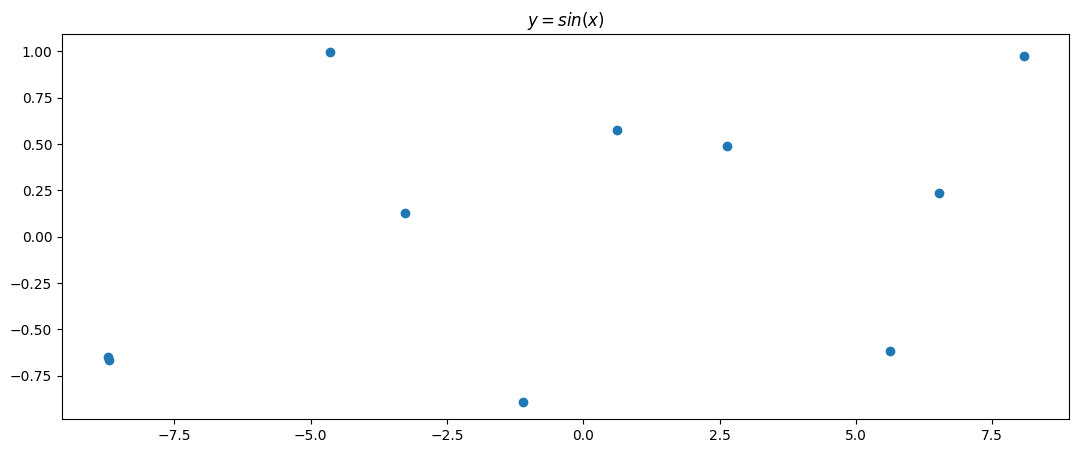

In [215]:
x_train = torch.rand(10)
x_train = x_train * 20.0 - 10.0

y_train = torch.sin(x_train)

plt.plot(x_train.numpy(), y_train.numpy(), 'o')
plt.title('$y = sin(x)$');

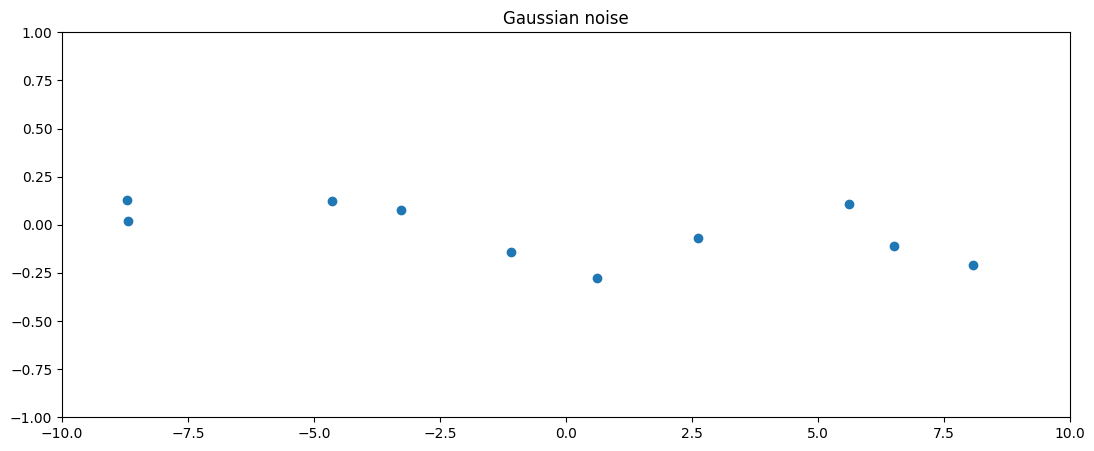

In [216]:
noise = torch.randn(y_train.shape) / 5.

plt.plot(x_train.numpy(), noise.numpy(), 'o')
plt.axis([-10, 10, -1, 1])
plt.title('Gaussian noise');

## 5. Обучение нейронной сети
В этом разделе собираются все ключевые элементы: модель, функция потерь, оптимизатор и цикл обучения. Пошагово разбирается процесс прямого прохода, вычисления ошибки, обратного распространения и обновления весов.

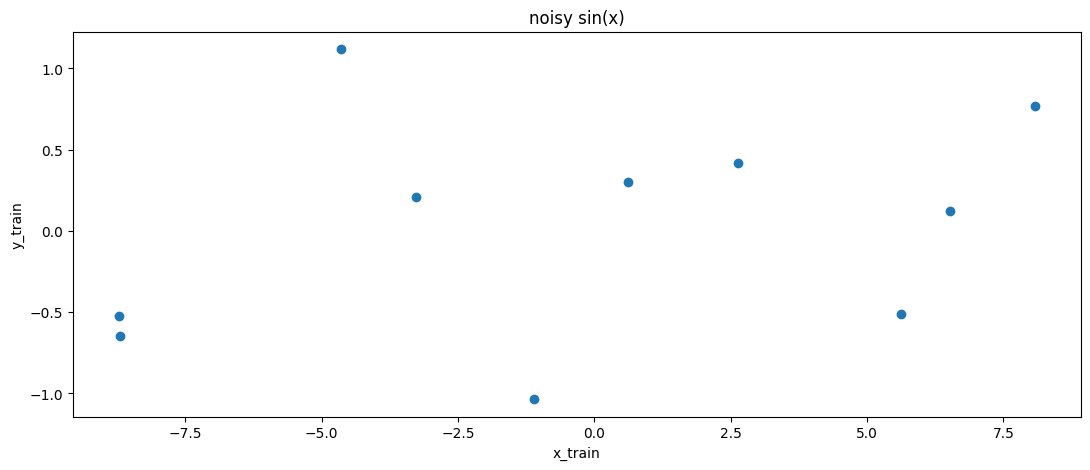

In [217]:
y_train = y_train + noise
plt.plot(x_train.numpy(), y_train.numpy(), 'o')
plt.title('noisy sin(x)')
plt.xlabel('x_train')
plt.ylabel('y_train');

In [218]:
x_train.unsqueeze_(1)
y_train.unsqueeze_(1);

In [ ]:
tmp = torch.Tensor([1,2,3, 4])
print(tmp)
print(tmp.unsqueeze(1))

# Validation dataset

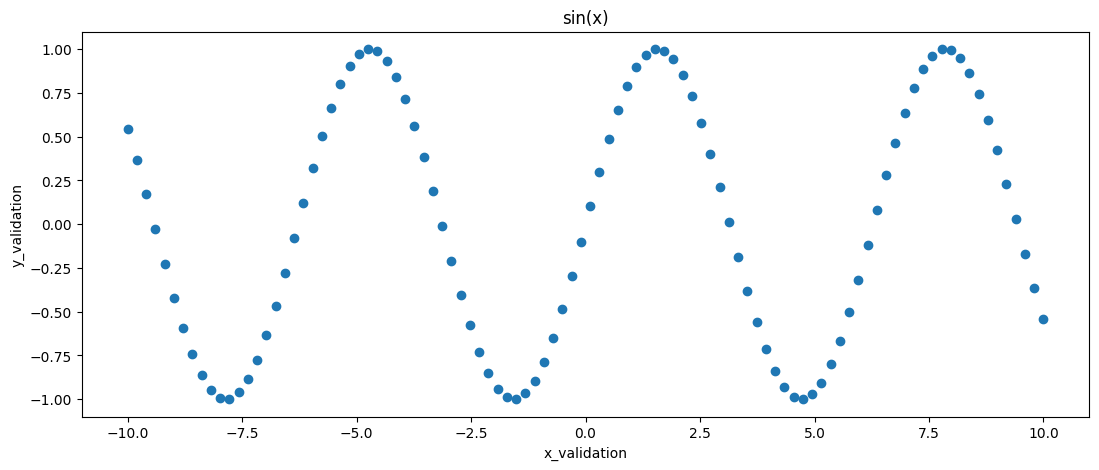

In [219]:
x_validation = torch.linspace(-10, 10, 100)
y_validation = torch.sin(x_validation.data)
#
# x_train = torch.rand(100)
# x_train = x_train * 20.0 - 10.0
#
# y_train = torch.sin(x_train)


plt.plot(x_validation.numpy(), y_validation.numpy(), 'o')
plt.title('sin(x)')
plt.xlabel('x_validation')
plt.ylabel('y_validation');

In [220]:
x_validation.unsqueeze_(1)
y_validation.unsqueeze_(1);

# Model construction

In [221]:
class SineNet(torch.nn.Module):
    def __init__(self, n_hidden_neurons):
        super(SineNet, self).__init__()
        self.fc1 = torch.nn.Linear(1, n_hidden_neurons)
        self.act1 = torch.nn.Sigmoid()
        self.fc2 = torch.nn.Linear(n_hidden_neurons, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act1(x)
        x = self.fc2(x)
        return x

sine_net = SineNet(3)

# Prediction

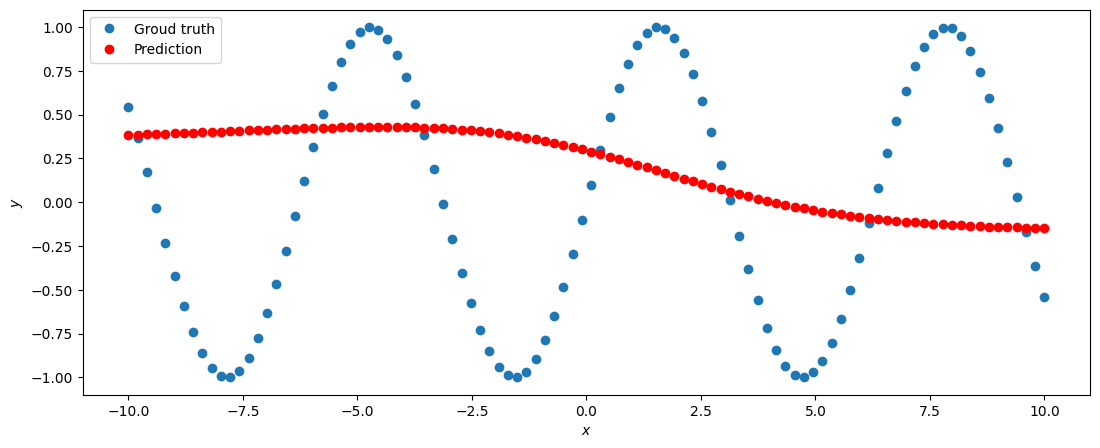

In [222]:
def predict(net, x, y):
    y_pred = net.forward(x)

    plt.plot(x.numpy(), y.numpy(), 'o', label='Groud truth')
    plt.plot(x.numpy(), y_pred.data.numpy(), 'o', c='r', label='Prediction');
    plt.legend(loc='upper left')
    plt.xlabel('$x$')
    plt.ylabel('$y$')

predict(sine_net, x_validation, y_validation)

# Optimizer

In [223]:
optimizer = torch.optim.Adam(sine_net.parameters(), lr=0.01)

# Loss function

In [226]:
def loss(pred, target):
    squares = (pred - target) ** 2
    return squares.mean()

# Training procedure

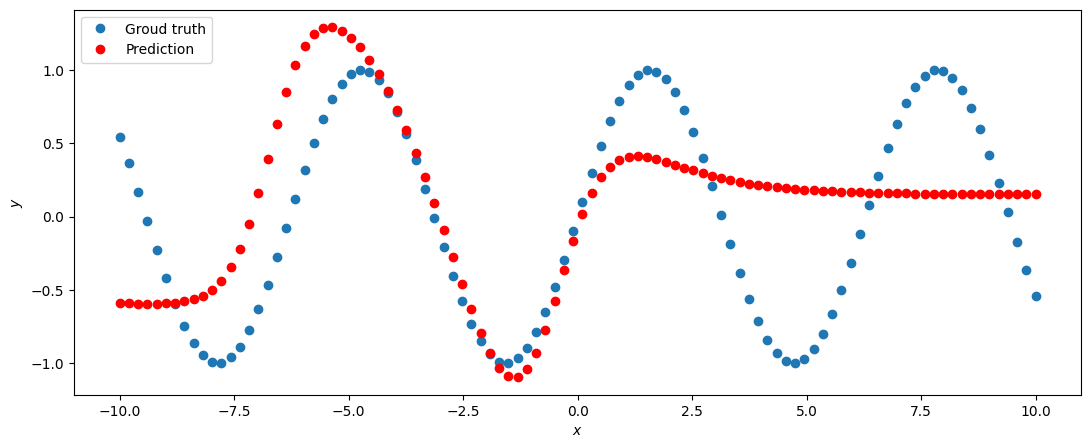

In [227]:
for epoch_index in range(10000):
    optimizer.zero_grad()

    y_pred = sine_net.forward(x_train)
    loss_val = loss(y_pred, y_train)

    loss_val.backward()

    optimizer.step()

predict(sine_net, x_validation, y_validation)

### Практика

В семинаре мы аппроксимировали синус (регрессия). Теперь давайте решим задачу бинарной классификации. Мы используем библиотеку sklearn для генерации 2D-точек, принадлежащих к двум разным классам.

In [228]:
# пример генерации датасета две луны

from sklearn.datasets import make_moons
import torch

X_np, y_np = make_moons(n_samples=200, noise=0.1)
X_train = torch.FloatTensor(X_np)
y_train = torch.FloatTensor(y_np).unsqueeze(1) # Приводим к размерности (200, 1)


### Задание(выполните и ответьте на вопрос)

1)Напишите класс ClassificationNet, унаследованный от torch.nn.Module. На вход подается 2 признака. Сделайте один скрытый слой (например, 10 нейронов) с функцией активации ReLU и выходной слой (1 нейрон) с функцией активации Sigmoid (так как мы предсказываем вероятности от 0 до 1).

2)Скопируйте цикл обучения из семинара. Измените функцию потерь: вместо самописной среднеквадратичной ошибки используйте встроенную бинарную кросс-энтропию — torch.nn.BCELoss().

3)Обучите модель в течение 1000 эпох.

В классическом ML (например, в scikit-learn) вы обычно просто вызываете метод model.fit(X, y). В PyTorch же цикл обучения расписан вручную. Какие ключевые этапы обучения нейросети скрываются под капотом fit() и написаны нами явно?

In [229]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

In [230]:
# Класс нейросети для бинарной классификации
class ClassificationNet(nn.Module):
    def __init__(self, n_hidden_neurons=10):
        super(ClassificationNet, self).__init__()
        # Вход: 2 признака -> скрытый слой (10 нейронов)
        self.fc1 = nn.Linear(2, n_hidden_neurons)
        # Активация скрытого слоя
        self.act1 = nn.ReLU()
        # Выходной слой: 10 нейронов -> 1 нейрон (вероятность класса)
        self.fc2 = nn.Linear(n_hidden_neurons, 1)
        # Сигмоида для получения вероятности от 0 до 1
        self.act2 = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.act1(x)
        x = self.fc2(x)
        x = self.act2(x)
        return x

Размер обучающей выборки: X=torch.Size([160, 2]), y=torch.Size([160, 1])
Размер валидационной выборки: X=torch.Size([40, 2]), y=torch.Size([40, 1])


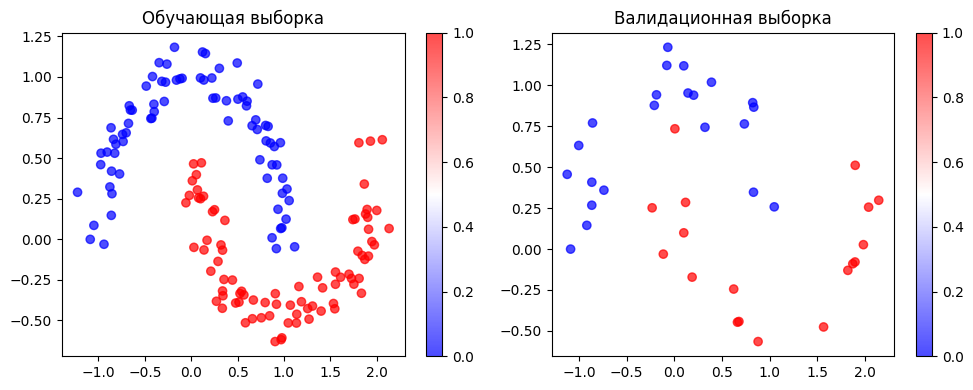

In [231]:
# Генерация данных "две луны"
X_np, y_np = make_moons(n_samples=200, noise=0.1, random_state=42)

# Разделение на обучающую и валидационную выборки
X_train, X_val, y_train, y_val = train_test_split(
    X_np, y_np, test_size=0.2, random_state=42
)

# Преобразование в тензоры PyTorch
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train).unsqueeze(1)  # (batch, 1)

X_val = torch.FloatTensor(X_val)
y_val = torch.FloatTensor(y_val).unsqueeze(1)

print(f"Размер обучающей выборки: X={X_train.shape}, y={y_train.shape}")
print(f"Размер валидационной выборки: X={X_val.shape}, y={y_val.shape}")

# Визуализация данных
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train.squeeze(), cmap='bwr',
            alpha=0.7)
plt.title('Обучающая выборка')
plt.colorbar()

plt.subplot(1, 2, 2)
plt.scatter(X_val[:, 0], X_val[:, 1], c=y_val.squeeze(), cmap='bwr', alpha=0.7)
plt.title('Валидационная выборка')
plt.colorbar()
plt.tight_layout()
plt.show()

In [232]:
# Создание модели
model = ClassificationNet(n_hidden_neurons=10)

# Функция потерь: бинарная кросс-энтропия
criterion = nn.BCELoss()

# Оптимизатор
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Количество эпох
epochs = 1000

# Для сохранения истории обучения
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

In [238]:
# Цикл обучения
for epoch in range(epochs):
    # --- ОБУЧЕНИЕ ---
    model.train()  # Переводим модель в режим обучения

    # Прямой проход
    y_pred = model(X_train)

    # Вычисление потерь
    loss = criterion(y_pred, y_train)

    # Обратный проход (backpropagation)
    optimizer.zero_grad()  # Обнуляем градиенты
    loss.backward()        # Вычисляем градиенты
    optimizer.step()       # Обновляем веса

    # Сохраняем значение потерь на обучении
    train_losses.append(loss.item())

    # --- ВАЛИДАЦИЯ ---
    model.eval()  # Переводим модель в режим оценки
    with torch.no_grad():  # Отключаем вычисление градиентов
        # Предсказания на валидационной выборке
        y_pred_val = model(X_val)
        val_loss = criterion(y_pred_val, y_val)
        val_losses.append(val_loss.item())

        # Вычисление точности
        train_acc = ((y_pred > 0.5).float() == y_train).float().mean().item()
        val_acc = ((y_pred_val > 0.5).float() == y_val).float().mean().item()

        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

    # Вывод прогресса каждые 100 эпох
    if (epoch + 1) % 100 == 0:
        print(f"Эпоха {epoch+1}/{epochs}")
        print(f"  Потери на обучении: {loss.item():.4f}, Точность: {train_acc:.4f}")
        print(f"  Потери на валидации: {val_loss.item():.4f}, Точность: {val_acc:.4f}")
        print("-" * 50)

Эпоха 100/1000
  Потери на обучении: 0.2852, Точность: 0.8562
  Потери на валидации: 0.2755, Точность: 0.8500
--------------------------------------------------
Эпоха 200/1000
  Потери на обучении: 0.1485, Точность: 0.9438
  Потери на валидации: 0.1623, Точность: 0.9500
--------------------------------------------------
Эпоха 300/1000
  Потери на обучении: 0.0539, Точность: 0.9875
  Потери на валидации: 0.0743, Точность: 0.9750
--------------------------------------------------
Эпоха 400/1000
  Потери на обучении: 0.0223, Точность: 1.0000
  Потери на валидации: 0.0479, Точность: 0.9750
--------------------------------------------------
Эпоха 500/1000
  Потери на обучении: 0.0125, Точность: 1.0000
  Потери на валидации: 0.0396, Точность: 0.9750
--------------------------------------------------
Эпоха 600/1000
  Потери на обучении: 0.0082, Точность: 1.0000
  Потери на валидации: 0.0362, Точность: 0.9750
--------------------------------------------------
Эпоха 700/1000
  Потери на обучени

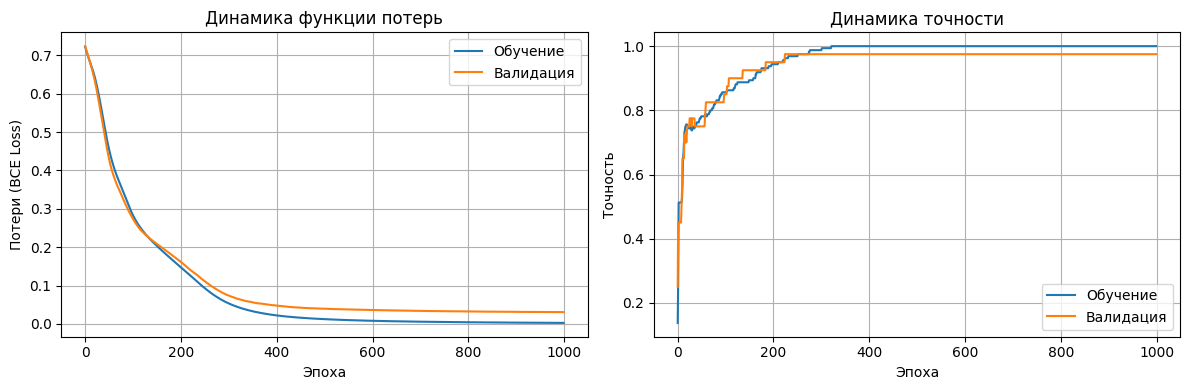

In [239]:
# График потерь
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Обучение')
plt.plot(val_losses, label='Валидация')
plt.xlabel('Эпоха')
plt.ylabel('Потери (BCE Loss)')
plt.title('Динамика функции потерь')
plt.legend()
plt.grid(True)

# График точности
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Обучение')
plt.plot(val_accuracies, label='Валидация')
plt.xlabel('Эпоха')
plt.ylabel('Точность')
plt.title('Динамика точности')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

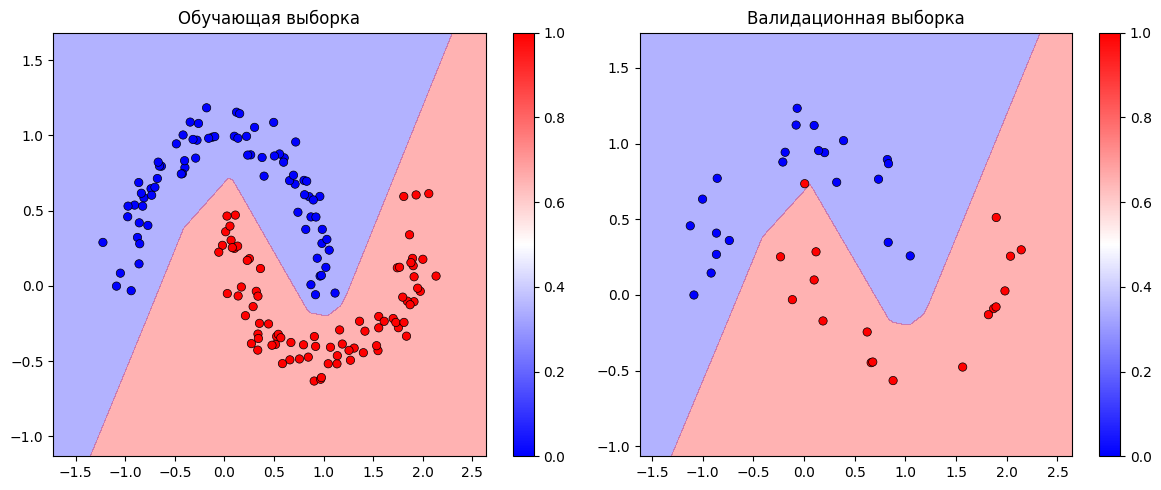

In [240]:
# Функция для визуализации разделяющей границы
def plot_decision_boundary(model, X, y, title):
    # Создаем сетку точек
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    # Получаем предсказания для всех точек сетки
    grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
    model.eval()
    with torch.no_grad():
        Z = model(grid).numpy().reshape(xx.shape)

    # Рисуем
    plt.contourf(xx, yy, Z, levels=[0, 0.5, 1], alpha=0.3, colors=['blue', 'red'])
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='black', linewidth=0.5)
    plt.title(title)
    plt.colorbar()

# Визуализация
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plot_decision_boundary(model, X_train.numpy(), y_train.numpy(), 'Обучающая выборка')

plt.subplot(1, 2, 2)
plot_decision_boundary(model, X_val.numpy(), y_val.numpy(), 'Валидационная выборка')

plt.tight_layout()
plt.show()

## Что скрывается под капотом fit()?

В методе `fit()` из scikit-learn скрыты следующие этапы, которые в PyTorch пишутся явно:

### 10 ключевых этапов обучения:

| Этап | В PyTorch | В sklearn |
|------|-----------|-----------|
| **1. Прямой проход** | `y_pred = model(X)` | ✓ |
| **2. Вычисление loss** | `loss = criterion(y_pred, y)` | ✓ |
| **3. Обнуление градиентов** | `optimizer.zero_grad()` | ✓ |
| **4. Обратный проход** | `loss.backward()` | ✓ |
| **5. Обновление весов** | `optimizer.step()` | ✓ |
| **6. Режимы train/eval** | `model.train()/eval()` | ✓ |
| **7. Отключение градиентов** | `with torch.no_grad():` | ✓ |
| **8. Перенос на устройство** | `.to(device)` | ✓ |
| **9. Мониторинг** | `print(f"Loss: {loss}")` | ✓ |
| **10. Валидация** | Отдельный цикл | ✓ |

### Преимущества явного подхода:
- **Полный контроль** над процессом
- **Гибкость** в настройке
- **Прозрачность** каждого шага
- Возможность **отладки**

### Недостатки:
- Больше кода
- Выше вероятность ошибок
- Требует понимания процесса

### Итог:
`fit()` в sklearn = "черный ящик" 🤖
Цикл в PyTorch = "конструктор" 🧩